In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/creditcard.csv')

# First look
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum().sum()}")
print(f"\nBasic stats:\n{df.describe()}")

Shape: (284807, 31)

Column types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
0

Basic stats:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.27

Legitimate: 284315 (99.83%)
Fraudulent: 492 (0.17%)


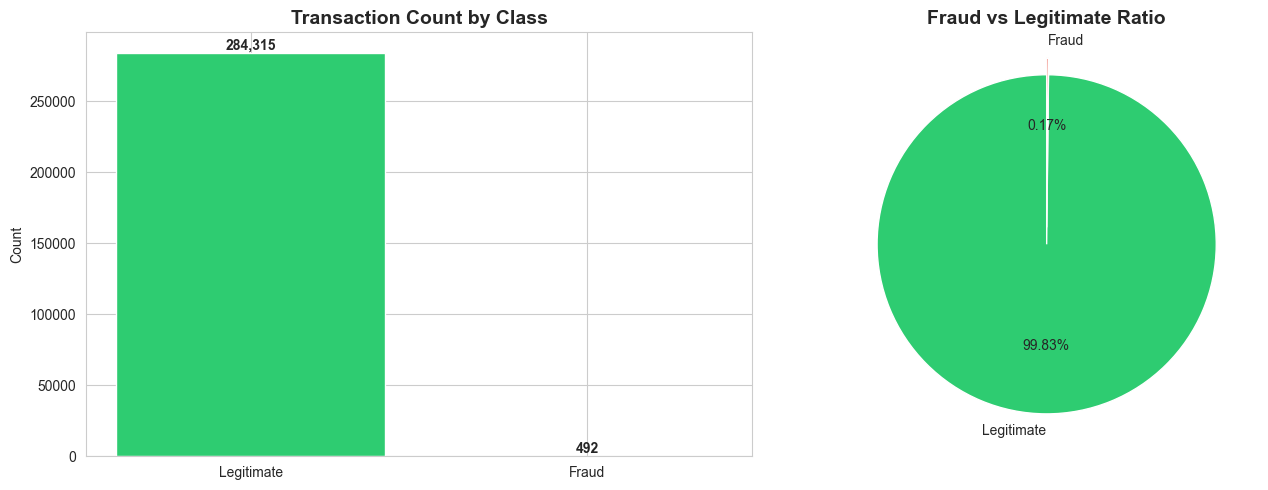

In [3]:
# Class distribution
fraud_counts = df['Class'].value_counts()
print(f"Legitimate: {fraud_counts[0]} ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"Fraudulent: {fraud_counts[1]} ({fraud_counts[1]/len(df)*100:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=colors)
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=colors, startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Fraud vs Legitimate Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

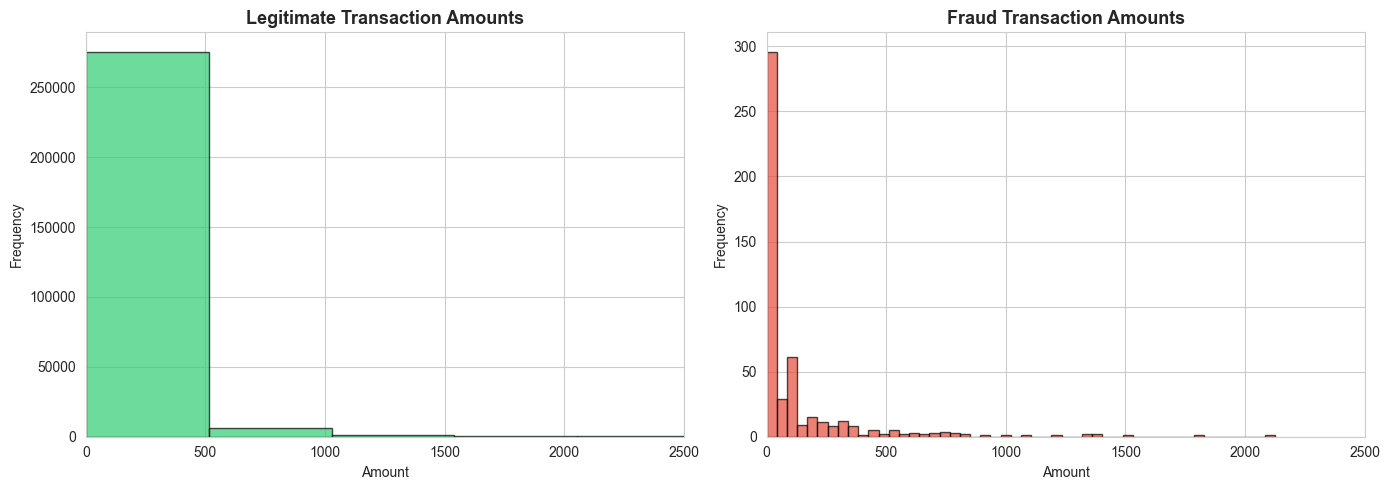

Legitimate transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution for legit vs fraud
for idx, cls in enumerate([0, 1]):
    subset = df[df['Class'] == cls]['Amount']
    label = 'Legitimate' if cls == 0 else 'Fraud'
    color = '#2ecc71' if cls == 0 else '#e74c3c'
    axes[idx].hist(subset, bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{label} Transaction Amounts', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Amount')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_xlim(0, 2500)

plt.tight_layout()
plt.savefig('../images/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("Legitimate transactions:")
print(df[df['Class']==0]['Amount'].describe())
print("\nFraudulent transactions:")
print(df[df['Class']==1]['Amount'].describe())

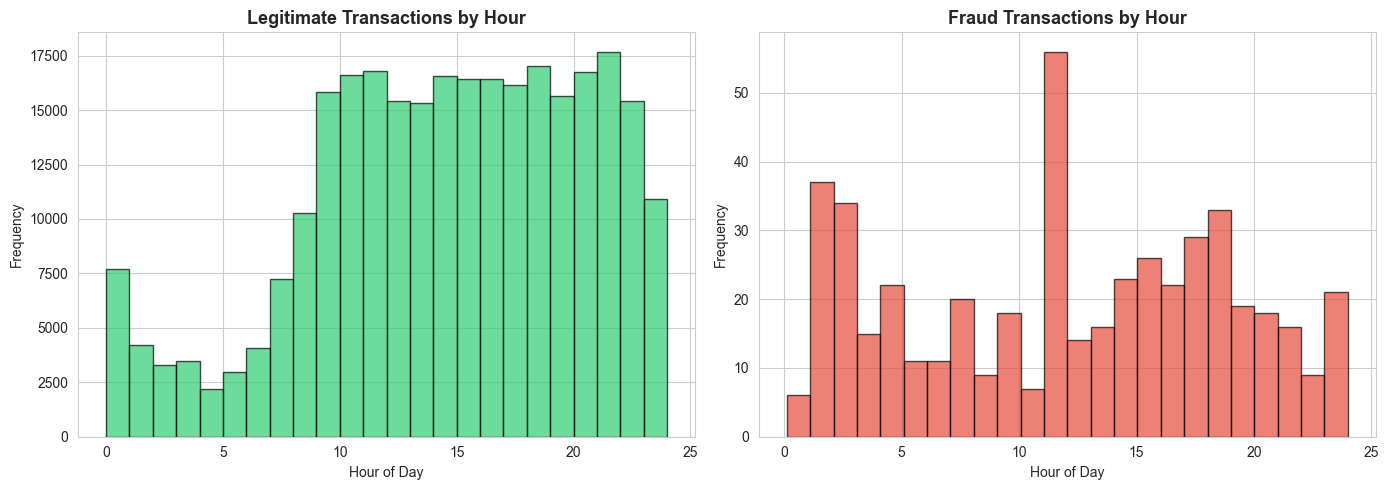

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert Time to hours (Time is seconds from first transaction)
df['Hour'] = (df['Time'] / 3600) % 24

# Transaction volume by hour
for idx, cls in enumerate([0, 1]):
    subset = df[df['Class'] == cls]
    label = 'Legitimate' if cls == 0 else 'Fraud'
    color = '#2ecc71' if cls == 0 else '#e74c3c'
    axes[idx].hist(subset['Hour'], bins=24, color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{label} Transactions by Hour', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Hour of Day')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../images/time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

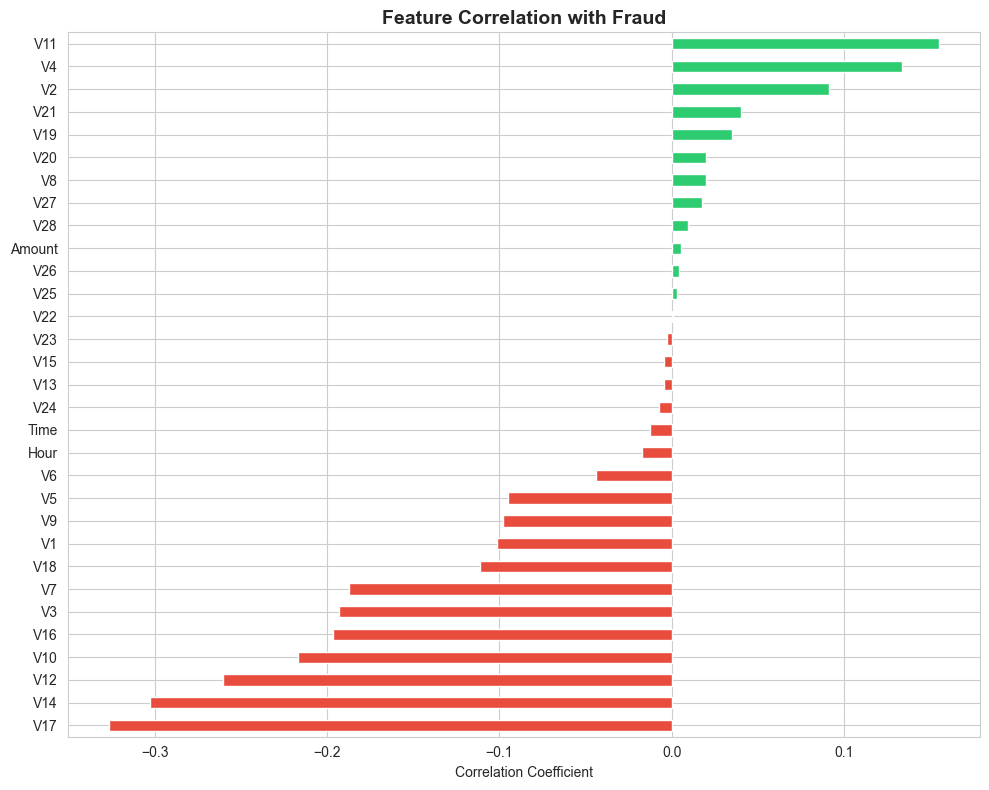

In [6]:
# Correlation of features with fraud
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlation with Fraud', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('../images/correlation_with_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Drop the Hour column we created (or keep it if you want)
df_clean = df.drop('Hour', axis=1)
df_clean.to_csv('../data/creditcard_clean.csv', index=False)
print("Clean data saved!")

Clean data saved!
